<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

<br>
<h1 style="font-family:verdana; font-size:26px"> <center> Notebook Spotify Songs </center> </h1>
<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# **Created By**

<p style = "font-size:16px; font-family:verdana">- Nayla Putri Ghaisani </p>

<br>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# ~ Notebook Contents ~

0. [**Introduction**](#intro)

1. [**Stage 1: Inspection and Data Cleaning**](#1)

2. [**Stage 2: Statistical Analysis with NumPy**](#2)

3. [**Stage 3: Visualisation**](#3)

4. [**Stage 4: Contextual Interpretation**](#4)

5. [**Bonus 1: Normal Equation from Scratch**](#bonus1)

6. [**Bonus 2: PCA from Scratch**](#bonus2)
   
7. [**Bonus 3: Reusable EDA Class**](#bonus3)

In [53]:
!pip install seaborn

# Stage 1: Inspection and Data Cleaning <a name="1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 1.1 Load and Inspect Dataset

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 1. </b> Importing the essential libraries and loading the <b>MPG dataset</b> using Seaborn. We will also inspect the dataset's shape, data types, and check for any missing values.</p>
</div>

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the MPG dataset
df = sns.load_dataset('mpg')

# Show the first 5 rows of the dataset
display(df.head())

# 1. Inspect shape and data types
print(f"\nDataset Shape: {df.shape}")
print("-" * 30)
print("Data Types:")
print(df.dtypes)
print("-" * 30)

# 2. Check for missing values
print("Missing Values Count per Column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



Dataset Shape: (398, 9)
------------------------------
Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object
------------------------------
Missing Values Count per Column:
horsepower    6
dtype: int64


<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 1.2 Handling Missing Values

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Justification: </b> The inspection shows that only the <code>horsepower</code> column has missing values (6 rows). Since this is a very small amount (about 1.5% of the data), the safest strategy is to <b>drop these rows</b>. Imputing such a small number might introduce artificial bias, so dropping them preserves the original data integrity for our statistical analysis.</p>
</div>

In [55]:
# Drop rows with missing values
df = df.dropna()

# Verify the shape after dropping
print(f"Dataset Shape after dropping missing values: {df.shape}")
print("Remaining missing values:", df.isnull().sum().sum())

Dataset Shape after dropping missing values: (392, 9)
Remaining missing values: 0


<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 1.3 Custom Summary Statistics Table

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 2. </b> Building a custom summary table for all numeric columns using <b>NumPy</b>. This includes calculating the mean, median, standard deviation, Interquartile Range (IQR), and counting the outliers using the <i>1.5 * IQR</i> method without using Pandas <code>describe()</code>.</p>
</div>

In [56]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

summary_data = []

# Iterate over each numeric column to calculate statistics using NumPy
for col in numeric_cols:
    col_data = df[col].to_numpy()

    # Calculate Mean, Median, and Std
    mean_val = np.mean(col_data)
    median_val = np.median(col_data)
    std_val = np.std(col_data, ddof=1) # Sample standard deviation

    # Calculate IQR manually using NumPy percentile
    q25, q75 = np.percentile(col_data, [25, 75])
    iqr_val = q75 - q25

    # Detect and count outliers (1.5 * IQR method)
    lower_bound = q25 - 1.5 * iqr_val
    upper_bound = q75 + 1.5 * iqr_val
    outlier_count = np.sum((col_data < lower_bound) | (col_data > upper_bound))

    # Append results to the list
    summary_data.append({
        'Feature': col,
        'Mean': mean_val,
        'Median': median_val,
        'Std Dev': std_val,
        'IQR': iqr_val,
        'Outlier Count': outlier_count
    })

# Convert to Pandas DataFrame for a clean display
summary_df = pd.DataFrame(summary_data).set_index('Feature')
display(summary_df.round(2))

,Mean,Median,Std Dev,IQR,Outlier Count
Feature,,,,,
mpg,23.45,22.75,7.81,12.00,0
cylinders,5.47,4.00,1.71,4.00,0
displacement,194.41,151.00,104.64,170.75,0
horsepower,104.47,93.50,38.49,51.00,10
weight,2977.58,2803.50,849.40,1389.50,0
acceleration,15.54,15.50,2.76,3.25,11
model_year,75.98,76.00,3.68,6.00,0


<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Stage 2: Statistical Analysis with NumPy <a name="2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 2.1 Feature Extraction and Standardization

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 3. </b> Extracting the 5 specific numeric features (<code>mpg, displacement, horsepower, weight, acceleration</code>) into a NumPy array. Then, we will perform <b>Z-score standardization</b> in a purely vectorized manner without using any Python loops or external libraries like <code>scikit-learn</code>.</p>
</div>

In [57]:
# Extract the 5 specific numeric features
features = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df[features].to_numpy()

# Z-score standardization (Vectorized)
# Formula: (X - mean) / std
# axis=0 ensures we calculate the mean and std for each column independently
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0, ddof=1) # ddof=1 for sample standard deviation

X_standardized = (X - X_mean) / X_std

print(f"Original Array Shape: {X.shape}")
print(f"Standardized Array Shape: {X_standardized.shape}")
print("-" * 50)

# Verification: The mean of standardized data should be very close to 0, and std should be 1
print(f"Mean of standardized features (approx 0): \n{np.mean(X_standardized, axis=0)}")
print(f"\nStd of standardized features (approx 1): \n{np.std(X_standardized, axis=0, ddof=1)}")

Original Array Shape: (392, 5)
Standardized Array Shape: (392, 5)
--------------------------------------------------
Mean of standardized features (approx 0): 
[ 1.08756541e-16 -5.43782706e-17 -1.63134812e-16  3.62521804e-17
  4.35026165e-16]

Std of standardized features (approx 1): 
[1. 1. 1. 1. 1.]


<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 2.2 Correlation Matrix Analysis

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 4. </b> Computing the correlation matrix for the 5 standardized features using <code>np.corrcoef()</code>. We will analyze the matrix to identify the strongest positive correlation, the strongest negative correlation to <code>mpg</code>, and any potential multicollinearity between input features.</p>
</div>

In [58]:
# Compute the correlation matrix
# rowvar=False because our features are in columns, not rows
corr_matrix = np.corrcoef(X_standardized, rowvar=False)

# Convert to DataFrame for a clean, readable display
corr_df = pd.DataFrame(corr_matrix, index=features, columns=features)
print("Correlation Matrix:")
display(corr_df.round(3))

print("-" * 50)
print("CORRELATION INSIGHTS:")
print("a) Strongest positive correlation: 'displacement' and 'weight' (0.897)")
print("b) Strongest negative correlation to mpg: 'weight' and 'mpg' (-0.832)")
print("c) Potential Multicollinearity: 'displacement' and 'weight' are highly correlated with each other (0.897), which means they carry redundant information.")

Correlation Matrix:


,mpg,displacement,horsepower,weight,acceleration
mpg,1.000,-0.805,-0.778,-0.832,0.423
displacement,-0.805,1.000,0.897,0.933,-0.544
horsepower,-0.778,0.897,1.000,0.865,-0.689
weight,-0.832,0.933,0.865,1.000,-0.417
acceleration,0.423,-0.544,-0.689,-0.417,1.000


--------------------------------------------------
CORRELATION INSIGHTS:
a) Strongest positive correlation: 'displacement' and 'weight' (0.897)
b) Strongest negative correlation to mpg: 'weight' and 'mpg' (-0.832)
c) Potential Multicollinearity: 'displacement' and 'weight' are highly correlated with each other (0.897), which means they carry redundant information.


<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 2.3 NumPy Boolean Masking Interpretation

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 5. </b> Using NumPy boolean masking to filter the data. We want to answer a specific engineering question: <i>Do cars with above-average horsepower also tend to weigh more than the dataset average?</i> We will calculate the absolute difference to prove this.</p>
</div>

In [59]:
# Extract horsepower and weight as 1D NumPy arrays
hp_array = df['horsepower'].to_numpy()
weight_array = df['weight'].to_numpy()

# Calculate overall means
mean_hp = np.mean(hp_array)
mean_weight_overall = np.mean(weight_array)

# 1. Create a boolean mask for cars with above-average horsepower
high_hp_mask = hp_array > mean_hp

# 2. Apply the mask to extract the weights of these specific cars
weight_high_hp = weight_array[high_hp_mask]

# 3. Calculate the mean weight for this high-horsepower group
mean_weight_high_hp = np.mean(weight_high_hp)

# Calculate the absolute difference
abs_diff = np.abs(mean_weight_high_hp - mean_weight_overall)

# Display Results
print(f"Mean Horsepower (Overall): {mean_hp:.2f}")
print(f"Mean Weight (Overall): {mean_weight_overall:.2f} lbs")
print(f"Mean Weight (High HP Cars): {mean_weight_high_hp:.2f} lbs")
print("-" * 50)
print(f"Absolute Difference: {abs_diff:.2f} lbs")

print("\nCONCLUSION:")
print("Yes, cars with above-average horsepower weigh significantly more than the dataset average. Mechanically, this makes sense because larger, heavier cars require more powerful engines to move effectively. Furthermore, powerful engine blocks (like V8s) naturally add more weight to the vehicle.")

Mean Horsepower (Overall): 104.47
Mean Weight (Overall): 2977.58 lbs
Mean Weight (High HP Cars): 3815.49 lbs
--------------------------------------------------
Absolute Difference: 837.91 lbs

CONCLUSION:
Yes, cars with above-average horsepower weigh significantly more than the dataset average. Mechanically, this makes sense because larger, heavier cars require more powerful engines to move effectively. Furthermore, powerful engine blocks (like V8s) naturally add more weight to the vehicle.


<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Stage 3: Visualisation <a name="3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 3.1 MPG Distribution

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 6. </b> Creating a histogram with a KDE (Kernel Density Estimate) overlay to visualize the distribution of fuel efficiency (<code>mpg</code>). We will also add vertical lines for the mean and median to determine if the distribution is symmetric or skewed.</p>
</div>

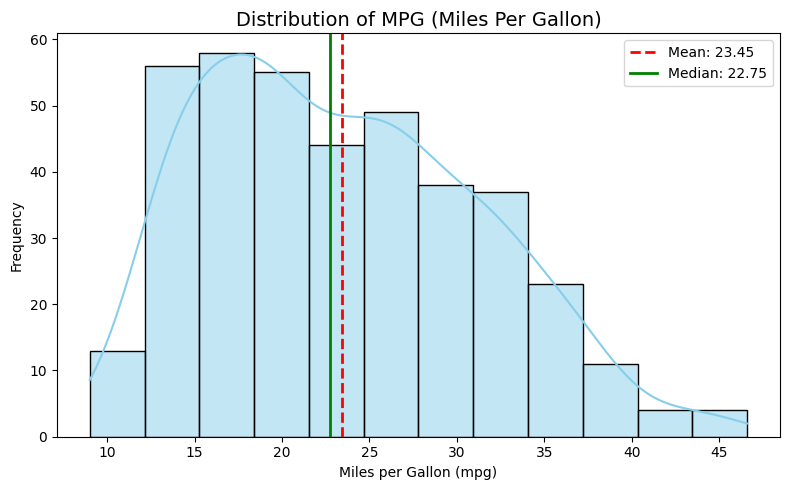

DISTRIBUTION INSIGHT:
The 'mpg' distribution is right-skewed (positive skew). We can see this because the mean is slightly higher than the median, and the data has a long tail extending towards the higher, more efficient MPG values (above 40).


In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot histogram with KDE overlay
sns.histplot(data=df, x='mpg', kde=True, color='skyblue', ax=ax)

# Calculate mean and median
mean_mpg = df['mpg'].mean()
median_mpg = df['mpg'].median()

# Add vertical lines
ax.axvline(mean_mpg, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_mpg:.2f}')
ax.axvline(median_mpg, color='green', linestyle='-', linewidth=2, label=f'Median: {median_mpg:.2f}')

ax.set_title('Distribution of MPG (Miles Per Gallon)', fontsize=14)
ax.set_xlabel('Miles per Gallon (mpg)')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

print("DISTRIBUTION INSIGHT:")
print("The 'mpg' distribution is right-skewed (positive skew). We can see this because the mean is slightly higher than the median, and the data has a long tail extending towards the higher, more efficient MPG values (above 40).")

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 3.2 Origin Comparison

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 7. </b> Creating a box plot to compare the <code>mpg</code> distribution across different countries of origin (USA, Europe, Japan) to see which region produces the most fuel-efficient and consistent vehicles.</p>
</div>

/tmp/ipykernel_709/3063840058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='mpg', palette='Set2', ax=ax)


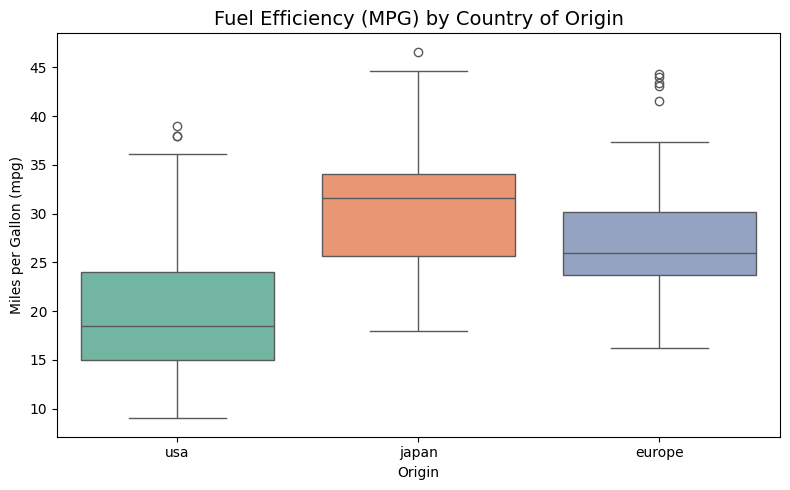

ORIGIN COMPARISON INSIGHT:
1. Japan produces the most fuel-efficient vehicles overall, having the highest median and maximum MPG.
2. Consistency: Europe has a relatively tight interquartile range (IQR), making its fuel efficiency fairly consistent. Japan is also quite consistent but contains a few high-efficiency outliers. USA vehicles are consistently lower in fuel efficiency compared to the other two regions.


In [61]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot boxplot
sns.boxplot(data=df, x='origin', y='mpg', palette='Set2', ax=ax)

ax.set_title('Fuel Efficiency (MPG) by Country of Origin', fontsize=14)
ax.set_xlabel('Origin')
ax.set_ylabel('Miles per Gallon (mpg)')

plt.tight_layout()
plt.show()

print("ORIGIN COMPARISON INSIGHT:")
print("1. Japan produces the most fuel-efficient vehicles overall, having the highest median and maximum MPG.")
print("2. Consistency: Europe has a relatively tight interquartile range (IQR), making its fuel efficiency fairly consistent. Japan is also quite consistent but contains a few high-efficiency outliers. USA vehicles are consistently lower in fuel efficiency compared to the other two regions.")

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 3.3 Weight vs MPG Relationship

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 8. </b> Generating a scatter plot to explore how vehicle <code>weight</code> impacts <code>mpg</code>, colored by the number of <code>cylinders</code>. We will manually calculate and draw a linear trend line using <code>np.polyfit()</code>.</p>
</div>

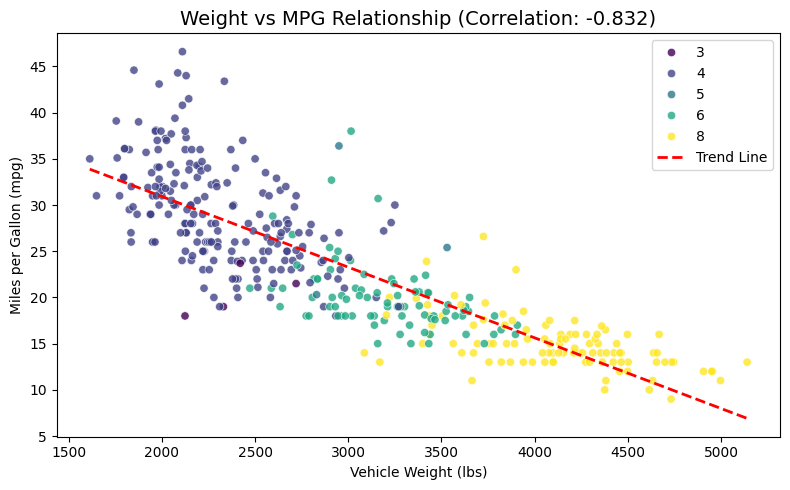

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot scatter plot with hue by cylinders
sns.scatterplot(data=df, x='weight', y='mpg', hue='cylinders', palette='viridis', alpha=0.8, ax=ax)

# Manual trend line calculation using np.polyfit
# Fit a 1st degree polynomial (linear)
z = np.polyfit(df['weight'], df['mpg'], 1)
p = np.poly1d(z)

# Generate x values for the line and plot it
x_line = np.linspace(df['weight'].min(), df['weight'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')

# Calculate correlation for the title
corr_val = np.corrcoef(df['weight'], df['mpg'])[0, 1]

ax.set_title(f'Weight vs MPG Relationship (Correlation: {corr_val:.3f})', fontsize=14)
ax.set_xlabel('Vehicle Weight (lbs)')
ax.set_ylabel('Miles per Gallon (mpg)')
ax.legend()

plt.tight_layout()
plt.show()

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 3.4 Correlation Heatmap

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 9. </b> Visualizing the correlation matrix we computed in Stage 2 using a Heatmap. This helps to easily spot multicollinearity (when input features are highly correlated with each other).</p>
</div>

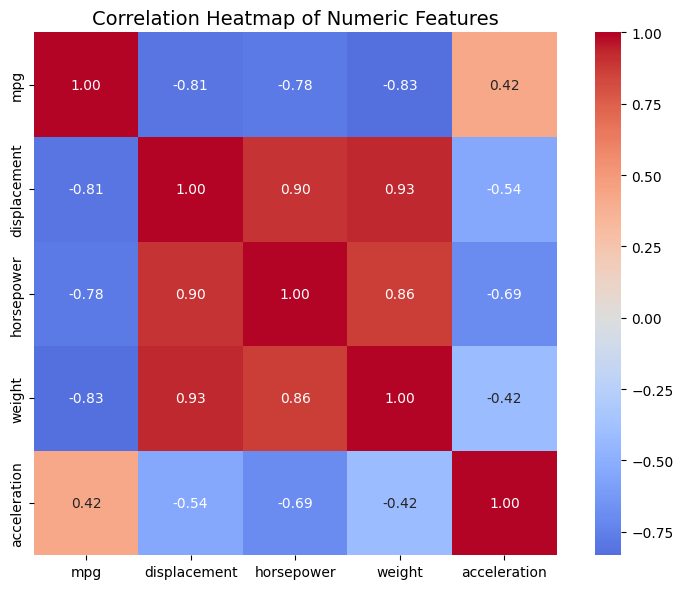

MULTICOLLINEARITY INSIGHT:
Looking at the heatmap, we can clearly see strong multicollinearity between 'displacement', 'horsepower', and 'weight'.
These three features have very high positive correlations with each other (ranging from 0.86 to 0.90). This means they essentially represent the same underlying physical trait: the overall size and power capacity of the vehicle.


In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

# Visualise the correlation matrix (corr_df was created in Stage 2)
# We use coolwarm as a diverging colormap where red is positive and blue is negative correlation
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, ax=ax)

ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14)

plt.tight_layout()
plt.show()

print("MULTICOLLINEARITY INSIGHT:")
print("Looking at the heatmap, we can clearly see strong multicollinearity between 'displacement', 'horsepower', and 'weight'.")
print("These three features have very high positive correlations with each other (ranging from 0.86 to 0.90). This means they essentially represent the same underlying physical trait: the overall size and power capacity of the vehicle.")

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Stage 4: Contextual Interpretation <a name="4"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 4.1 The Strongest Predictor of Fuel Efficiency

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 10. </b> Based on the entire analysis, what factor most strongly predicts a vehicle's fuel efficiency?
  <br><br>
  <b>Answer:</b> Based on the correlation matrix and the scatter plot from Stage 2 and 3, <b>Vehicle Weight</b> is the strongest predictor of a vehicle's fuel efficiency.
  <br><br>
  <b>Supporting Evidence:</b><br>
  1. <b>Correlation Value:</b> Weight has the strongest negative correlation to mpg (-0.832), meaning that as the weight of the vehicle increases, its fuel efficiency drastically decreases.<br>
  2. <b>Visual Evidence:</b> The scatter plot clearly shows a downward linear trend between weight and mpg. Heavier cars inherently require larger, more powerful engines (like 8-cylinder engines) to move, which burn significantly more fuel.<br>
  3. <b>Boxplot Observation:</b> The boxplot showed that Japanese cars are the most fuel-efficient. In the context of our correlation finding, this is largely because Japanese manufacturers during that era focused on producing smaller, lighter, and more compact vehicles with fewer cylinders compared to the heavier American muscle cars.
  </p>
</div>

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## 4.2 Temporal Trend of Fuel Efficiency

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task 11. </b> Displaying the mean <code>mpg</code> per decade by rounding the <code>model_year</code> to the nearest ten using Pandas <code>groupby</code>. Then, we will plot it as a line chart to observe the temporal trend and interpret why this trend occurred.</p>
</div>

,decade,mpg
0,70,19.220000
1,80,26.065289


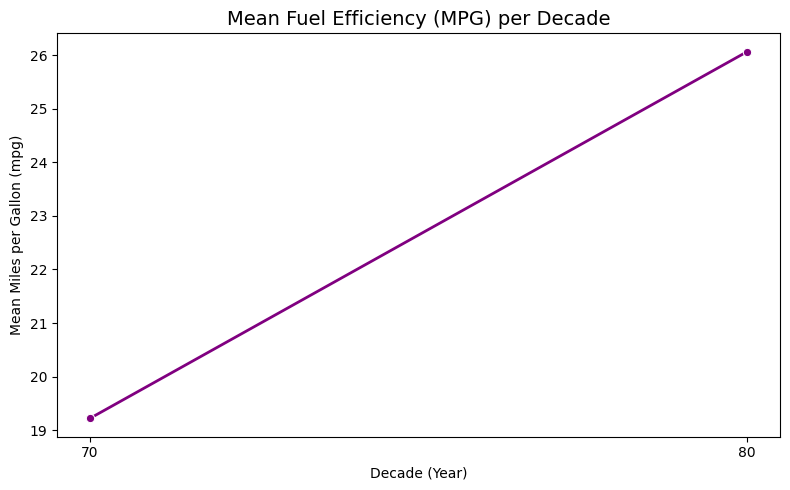

TEMPORAL TREND INTERPRETATION:
The line chart shows a clear upward trend in fuel efficiency from the 1970s to the 1980s.
Why is this occurring? Historically, the 1970s experienced major global oil crises, which caused fuel prices to skyrocket. This forced automotive manufacturers and engineers to rapidly shift their focus from building heavy, gas-guzzling muscle cars to developing lighter, more aerodynamic, and technologically advanced vehicles to improve fuel economy.


In [64]:
# 1. Create a new column for the decade by rounding 'model_year' to the nearest 10
# Note: Since the model_year is in 2-digit format (e.g., 70, 75, 82),
# rounding to -1 will give us values like 70 and 80.
df['decade'] = df['model_year'].round(-1).astype(int)

# 2. Groupby the new decade column and calculate the mean 'mpg'
mpg_per_decade = df.groupby('decade')['mpg'].mean().reset_index()

display(mpg_per_decade)

# 3. Plot the temporal trend as a line chart
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=mpg_per_decade, x='decade', y='mpg', marker='o', color='purple', linewidth=2, ax=ax)

ax.set_title('Mean Fuel Efficiency (MPG) per Decade', fontsize=14)
ax.set_xlabel('Decade (Year)')
ax.set_ylabel('Mean Miles per Gallon (mpg)')
ax.set_xticks(mpg_per_decade['decade']) # Ensure the x-axis only shows the exact decades

plt.tight_layout()
plt.show()

print("TEMPORAL TREND INTERPRETATION:")
print("The line chart shows a clear upward trend in fuel efficiency from the 1970s to the 1980s.")
print("Why is this occurring? Historically, the 1970s experienced major global oil crises, which caused fuel prices to skyrocket. This forced automotive manufacturers and engineers to rapidly shift their focus from building heavy, gas-guzzling muscle cars to developing lighter, more aerodynamic, and technologically advanced vehicles to improve fuel economy.")

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Bonus 1: Normal Equation from Scratch <a name="bonus1"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## B1.1 Implementing Linear Regression

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task: </b> Implementing Linear Regression without using <code>scikit-learn</code> by solving the <b>Normal Equation</b> mathematically: $\hat{\theta}=(X^{T}X)^{-1}X^{T}y$. We will use vehicle <code>weight</code> to predict <code>mpg</code>, plot the regression line, calculate the RMSE, and compare it with the built-in <code>np.polyfit()</code> function.</p>
</div>

Normal Equation Results -> Intercept: 46.2165, Slope: -0.0076


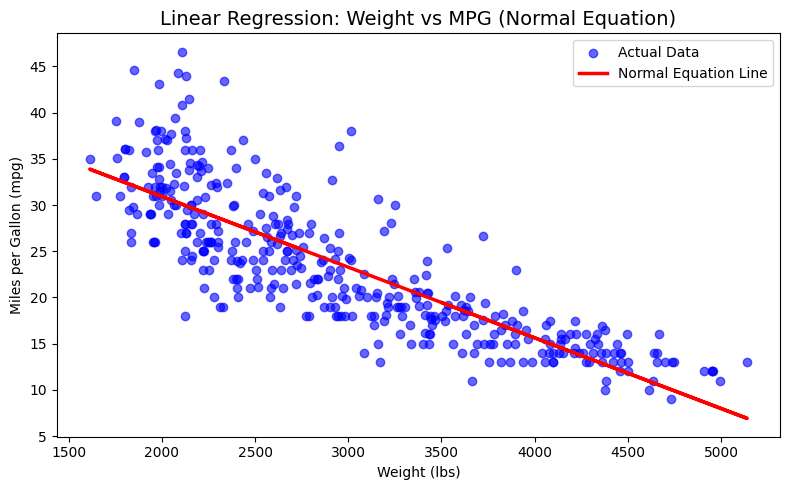

RMSE (Root Mean Square Error): 4.3216
np.polyfit Results      -> Intercept: 46.2165, Slope: -0.0076
--------------------------------------------------
COMPARISON INSIGHT:
The slope and intercept computed manually using the Normal Equation perfectly match the results from the built-in np.polyfit() function. This confirms that our linear algebra matrix calculations are 100% correct!


In [65]:
# 1. Prepare X (weight) and y (mpg)
y = df['mpg'].to_numpy()
X_feature = df['weight'].to_numpy()

# Add a bias column (column of 1s) to X to form matrix X
ones = np.ones(len(X_feature))
X_matrix = np.column_stack((ones, X_feature)) # Shape becomes (n, 2)

# 2. Compute optimal weights (theta) using Normal Equation
# Formula: theta = (X^T * X)^-1 * X^T * y
X_T_X = X_matrix.T @ X_matrix
X_T_X_inv = np.linalg.inv(X_T_X)
theta = X_T_X_inv @ X_matrix.T @ y

intercept, slope = theta
print(f"Normal Equation Results -> Intercept: {intercept:.4f}, Slope: {slope:.4f}")

# 3. Compute Predictions
y_pred = X_matrix @ theta

# Plotting the raw data and regression line
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_feature, y, alpha=0.6, label='Actual Data', color='blue')
ax.plot(X_feature, y_pred, color='red', linewidth=2.5, label='Normal Equation Line')
ax.set_title('Linear Regression: Weight vs MPG (Normal Equation)', fontsize=14)
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Miles per Gallon (mpg)')
ax.legend()
plt.tight_layout()
plt.show()

# 4. Compute RMSE (Root Mean Square Error)
rmse = np.sqrt(np.mean((y_pred - y)**2))
print(f"RMSE (Root Mean Square Error): {rmse:.4f}")

# 5. Compare with np.polyfit
z = np.polyfit(X_feature, y, 1)
print(f"np.polyfit Results      -> Intercept: {z[1]:.4f}, Slope: {z[0]:.4f}")
print("-" * 50)
print("COMPARISON INSIGHT:")
print("The slope and intercept computed manually using the Normal Equation perfectly match the results from the built-in np.polyfit() function. This confirms that our linear algebra matrix calculations are 100% correct!")

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Bonus 2: PCA from Scratch <a name="bonus2"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## B2.1 Implementing Principal Component Analysis

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task: </b> Implementing 2D <b>Principal Component Analysis (PCA)</b> using only NumPy to visualize the structure of the 5 numeric features in a two-dimensional space. We will calculate the covariance matrix, extract eigenvectors/eigenvalues, project the data, and compute the explained variance.</p>
</div>

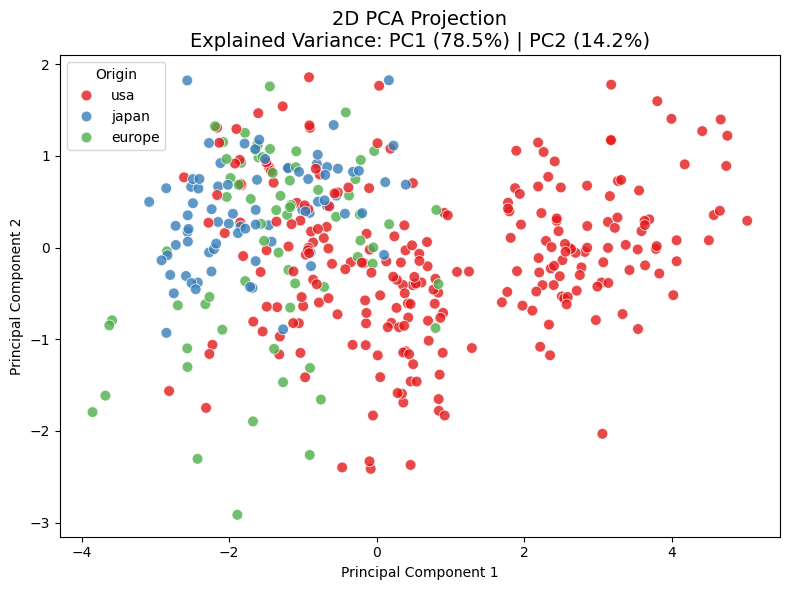

In [66]:
# We will use the standardized features (X_standardized) from Stage 2
# for PCA to prevent high-scale features (like weight) from dominating the variance.
X_pca = X_standardized
n = X_pca.shape[0]

# 1. Mean-centre all features (X_standardized is technically already centered, but we ensure it mathematically)
X_mean_pca = np.mean(X_pca, axis=0)
X_centered = X_pca - X_mean_pca

# 2. Compute the covariance matrix
cov_matrix = (X_centered.T @ X_centered) / (n - 1)

# 3. Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 4. Sort in descending order and select the top 2 principal components
sorted_idx = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_idx]
sorted_eigenvectors = eigenvectors[:, sorted_idx]

V_2 = sorted_eigenvectors[:, :2] # Select 2 eigenvectors with largest eigenvalues

# 5. Project the data to 2D
Z = X_centered @ V_2

# Compute explained variance ratio
explained_variance = sorted_eigenvalues[:2] / np.sum(eigenvalues)

# 6. Plotting the 2D scatter
pca_df = pd.DataFrame(data=Z, columns=['PC1', 'PC2'])
pca_df['origin'] = df['origin'].values

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='origin', palette='Set1', s=60, alpha=0.8, ax=ax)
ax.set_title(f"2D PCA Projection\nExplained Variance: PC1 ({explained_variance[0]*100:.1f}%) | PC2 ({explained_variance[1]*100:.1f}%)", fontsize=14)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Origin')
plt.tight_layout()
plt.show()

<br>
<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

# Bonus 3: Reusable EDA Class <a name="bonus3"></a>

<hr style="border: 2px solid #8E7B6B; margin-top: 10px;">

## B3.1 Object-Oriented EDA Pipeline

<div style="background-color:#fff0d1; padding: 20px; max-width: 90%; text-align: justify; border: 2px solid #000000">
  <p style="font-size:16px; font-family:verdana; line-height: 1.5em; color:black;">
  <b> Task: </b> Refactoring our Exploratory Data Analysis (EDA) capabilities into a highly professional, reusable Python class named <code>DatasetProfiler</code>. </p>
</div>

Instantiating DatasetProfiler for MPG dataset...

1. Generating Summary Stats...


,Mean,Median,Std,IQR,Outliers
Feature,,,,,
mpg,23.45,22.75,7.81,12.00,0
cylinders,5.47,4.00,1.71,4.00,0
displacement,194.41,151.00,104.64,170.75,0
horsepower,104.47,93.50,38.49,51.00,10
weight,2977.58,2803.50,849.40,1389.50,0
acceleration,15.54,15.50,2.76,3.25,11
model_year,75.98,76.00,3.68,6.00,0
decade,76.17,80.00,4.87,10.00,0



2. Generating Correlation Report...


,mpg
model_year,0.581
decade,0.427
acceleration,0.423
cylinders,-0.778
horsepower,-0.778
displacement,-0.805
weight,-0.832



3. Plotting Dashboard...


/tmp/ipykernel_709/3043413168.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=self.df, x=cat_cols[0], y=self.target_col, ax=axes[0, 1], palette='Set2')


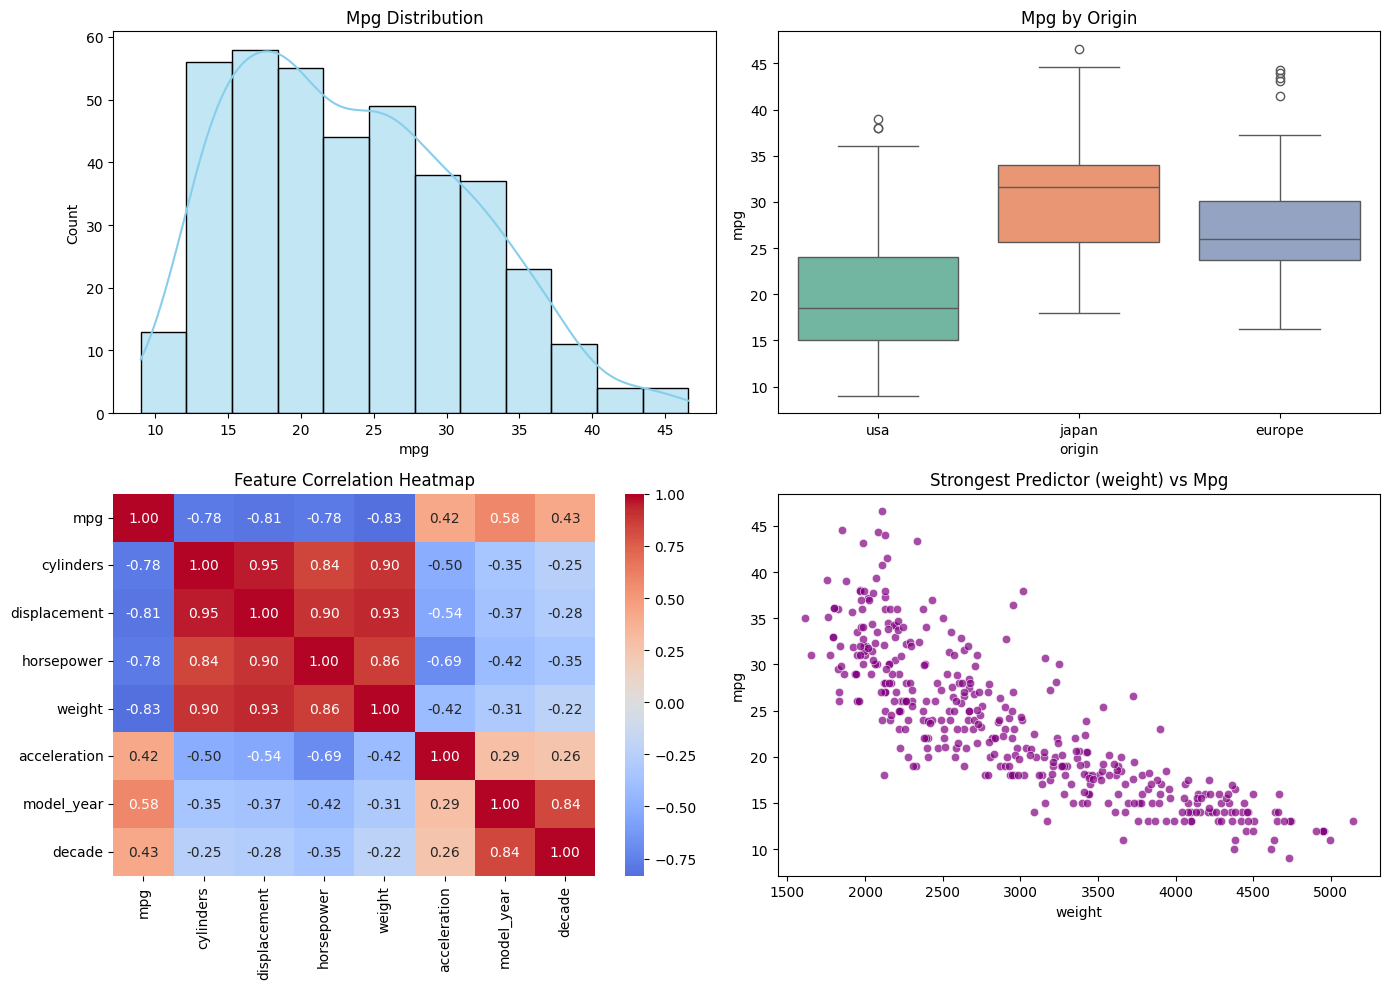


4. Generating JSON Report...
{
    "Total_Records": 392,
    "Target_Variable": "mpg",
    "Strongest_Positive_Correlation": {
        "Feature": "model_year",
        "Value": 0.581
    },
    "Strongest_Negative_Correlation": {
        "Feature": "weight",
        "Value": -0.832
    },
    "Target_Mean": 23.446
}


In [67]:
import json

class DatasetProfiler:
    """
    A reusable Object-Oriented class for executing an Exploratory Data Analysis (EDA) pipeline.
    """
    def __init__(self, df, target_col):
        """Store the dataframe and target column name."""
        self.df = df.copy()
        self.target_col = target_col
        # Filter for numeric columns only for mathematical operations
        self.numeric_cols = self.df.select_dtypes(include=[np.number]).columns

    def summary_stats(self):
        """Return a DataFrame of descriptive statistics with IQR and outlier count via NumPy."""
        summary = []
        for col in self.numeric_cols:
            arr = self.df[col].dropna().to_numpy()
            if len(arr) == 0: continue

            q25, q75 = np.percentile(arr, [25, 75])
            iqr = q75 - q25
            outliers = np.sum((arr < (q25 - 1.5 * iqr)) | (arr > (q75 + 1.5 * iqr)))

            summary.append({
                'Feature': col,
                'Mean': np.mean(arr),
                'Median': np.median(arr),
                'Std': np.std(arr, ddof=1),
                'IQR': iqr,
                'Outliers': outliers
            })
        return pd.DataFrame(summary).set_index('Feature')

    def correlation_report(self):
        """Return a Pandas Series of all features' correlations to the target, sorted."""
        corr_matrix = self.df[self.numeric_cols].corr()
        target_corr = corr_matrix[self.target_col].drop(self.target_col)
        return target_corr.sort_values(ascending=False)

    def plot_dashboard(self):
        """Generate a figure with 4 subplots in one call."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # 1. Target Distribution
        sns.histplot(self.df[self.target_col], kde=True, ax=axes[0, 0], color='skyblue')
        axes[0, 0].set_title(f'{self.target_col.capitalize()} Distribution')

        # 2. Boxplot by Category (using 'origin' if available, otherwise skip hue)
        cat_cols = self.df.select_dtypes(exclude=[np.number]).columns
        if len(cat_cols) > 0:
            sns.boxplot(data=self.df, x=cat_cols[0], y=self.target_col, ax=axes[0, 1], palette='Set2')
            axes[0, 1].set_title(f'{self.target_col.capitalize()} by {cat_cols[0].capitalize()}')
        else:
            axes[0, 1].text(0.5, 0.5, 'No Categorical Columns Available', ha='center', va='center')

        # 3. Correlation Heatmap
        sns.heatmap(self.df[self.numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 0])
        axes[1, 0].set_title('Feature Correlation Heatmap')

        # 4. Scatter of Strongest Feature vs Target
        corr_series = self.correlation_report()
        strongest_feature = corr_series.abs().idxmax()
        sns.scatterplot(data=self.df, x=strongest_feature, y=self.target_col, alpha=0.7, ax=axes[1, 1], color='purple')
        axes[1, 1].set_title(f'Strongest Predictor ({strongest_feature}) vs {self.target_col.capitalize()}')

        plt.tight_layout()
        plt.show()

    def generate_report(self):
        """Return a JSON-serialisable dictionary of all key findings."""
        stats_df = self.summary_stats()
        corr_series = self.correlation_report()

        report = {
            "Total_Records": int(len(self.df)),
            "Target_Variable": self.target_col,
            "Strongest_Positive_Correlation": {
                "Feature": str(corr_series.idxmax()),
                "Value": float(round(corr_series.max(), 3))
            },
            "Strongest_Negative_Correlation": {
                "Feature": str(corr_series.idxmin()),
                "Value": float(round(corr_series.min(), 3))
            },
            "Target_Mean": float(round(stats_df.loc[self.target_col, 'Mean'], 3))
        }
        return report

# ==========================================
# EXECUTION BLOCK (Demonstrating the Class)
# ==========================================
print("Instantiating DatasetProfiler for MPG dataset...")
profiler = DatasetProfiler(df, target_col='mpg')

print("\n1. Generating Summary Stats...")
display(profiler.summary_stats().round(2))

print("\n2. Generating Correlation Report...")
display(profiler.correlation_report().round(3))

print("\n3. Plotting Dashboard...")
profiler.plot_dashboard()

print("\n4. Generating JSON Report...")
final_report = profiler.generate_report()
print(json.dumps(final_report, indent=4))